In [35]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
file_path = '/content/cleaned_discipline_specific_pathways (1).csv'
df = pd.read_csv(file_path)

In [31]:
print("Column Names in Dataset:")
print(df.columns.tolist())

df.head()

Column Names in Dataset:
['Focal Award', 'Discipline', 'Pathway Award', '# Awardees w/ This Award', 'Percentage of Awardees with This Award', 'Mean Academic Age at Time of Award', 'Has Pathway Award', 'Has Focal Award']


,Focal Award,Discipline,Pathway Award,# Awardees w/ This Award,Percentage of Awardees with This Award,Mean Academic Age at Time of Award,Has Pathway Award,Has Focal Award
0,A-T Children's Project | AT Research Grants,Pathology,Association for Molecular Pathology | AMP Youn...,1.0,1.0,10.0,1,1
1,A-T Children's Project | AT Research Grants,Pathology,A-T Children's Project | AT Research Grants,1.0,1.0,21.0,1,1
2,Abdullah bin Hamad Al-Attiyah International Fo...,"Engineering, various","Society of Petroleum Engineers | Health, Safet...",1.0,1.0,31.0,1,1
3,Abdullah bin Hamad Al-Attiyah International Fo...,"Engineering, various","Geological Society of America, The | Michel T ...",1.0,1.0,21.0,1,1
4,Abdullah bin Hamad Al-Attiyah International Fo...,Environmental Sciences,"Society of Petroleum Engineers | Health, Safet...",1.0,1.0,31.0,1,1


In [24]:
print("\nSummary Statistics:")
print(df.describe())

print("\nBasic Info:")
print(df.info())

print("\nUnique Disciplines:")
print(df['Discipline'].nunique())

print("\nUnique Awards:")
print(df['Focal Award'].nunique())


Summary Statistics:
       # Awardees w/ This Award  Percentage of Awardees with This Award  \
count             182704.000000                           182705.000000   
mean                   1.251270                                0.559009   
std                    1.538589                                0.388555   
min                    1.000000                                0.005000   
25%                    1.000000                                0.200000   
50%                    1.000000                                0.500000   
75%                    1.000000                                1.000000   
max                  154.000000                                1.000000   

       Mean Academic Age at Time of Award  
count                       169798.000000  
mean                            16.920694  
std                             11.359194  
min                              0.000000  
25%                              7.000000  
50%                             15.0000

In [25]:
# award liklihood across disciplines

discipline_award_counts = pd.crosstab(df['Discipline'], df['Focal Award'])
chi2, p, _, _ = stats.chi2_contingency(discipline_award_counts)
print("\nChi-Square Test for Award Likelihood Across Disciplines:")
print(f"Chi2: {chi2}, p-value: {p}")


Chi-Square Test for Award Likelihood Across Disciplines:
Chi2: 5583615.282427399, p-value: 0.0


The extremely high chi-square statistic and p-value < 0.05 indicate that award distribution significantly varies across disciplines. This suggests that some disciplines are more likely to receive certain awards than others.

In [26]:
#  impact of prior awards on receiving another award

df['Has Pathway Award'] = df['Pathway Award'].apply(lambda x: 1 if pd.notna(x) else 0)
df['Has Focal Award'] = df['Focal Award'].apply(lambda x: 1 if pd.notna(x) else 0)
prior_award_counts = pd.crosstab(df['Has Pathway Award'], df['Has Focal Award'])
chi2, p, _, _ = stats.chi2_contingency(prior_award_counts)
print("\nChi-Square Test for Impact of Prior Awards on Receiving Another Award:")
print(f"Chi2: {chi2}, p-value: {p}")


Chi-Square Test for Impact of Prior Awards on Receiving Another Award:
Chi2: 0.0, p-value: 1.0


The chi-square statistic of 0 suggests that the two variables (having a prior award and receiving a focal award) are completely independent—meaning that receiving a prior award does not affect the likelihood of receiving a future award in this dataset.

In [27]:
# do different disciplines favor specific pathway awards?

discipline_pathway_counts = pd.crosstab(df['Discipline'], df['Pathway Award'])
chi2, p, _, _ = stats.chi2_contingency(discipline_pathway_counts)
print("\nChi-Square Test for Relationship Between Disciplines and Pathway Awards:")
print(f"Chi2: {chi2}, p-value: {p}")


Chi-Square Test for Relationship Between Disciplines and Pathway Awards:
Chi2: 4501730.299500342, p-value: 0.0


The significant p-value suggests that disciplines and pathway awards are not independent. This means that some disciplines are more associated with certain pathway awards than others.

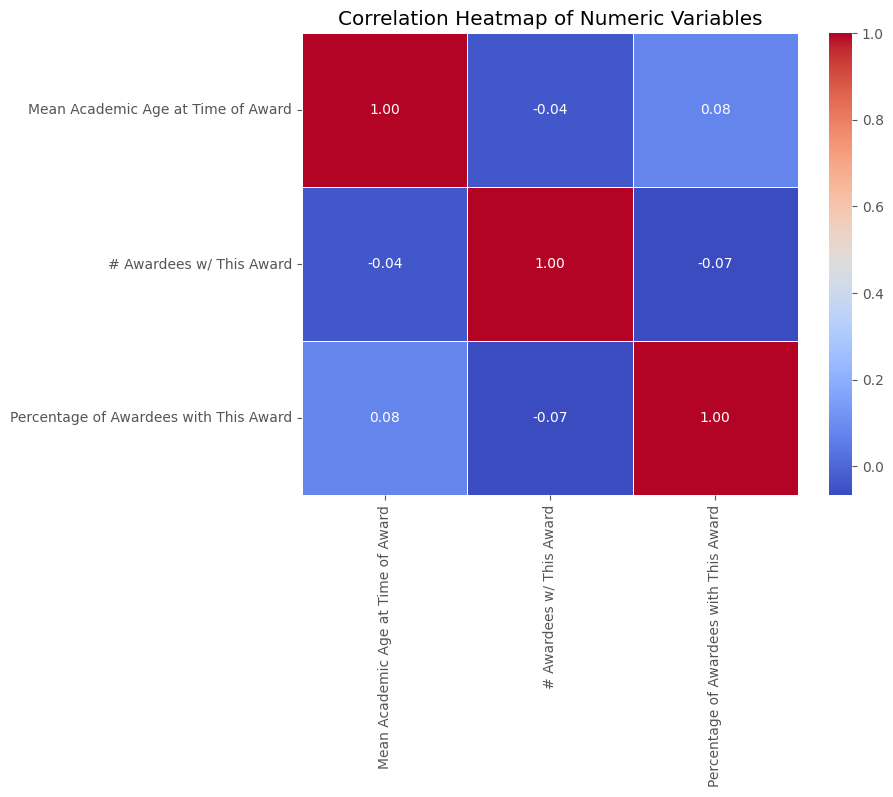

In [39]:
plt.style.use('ggplot')

# correlation matrix

plt.figure(figsize=(8, 6))
corr_matrix = df[["Mean Academic Age at Time of Award", "# Awardees w/ This Award", "Percentage of Awardees with This Award"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

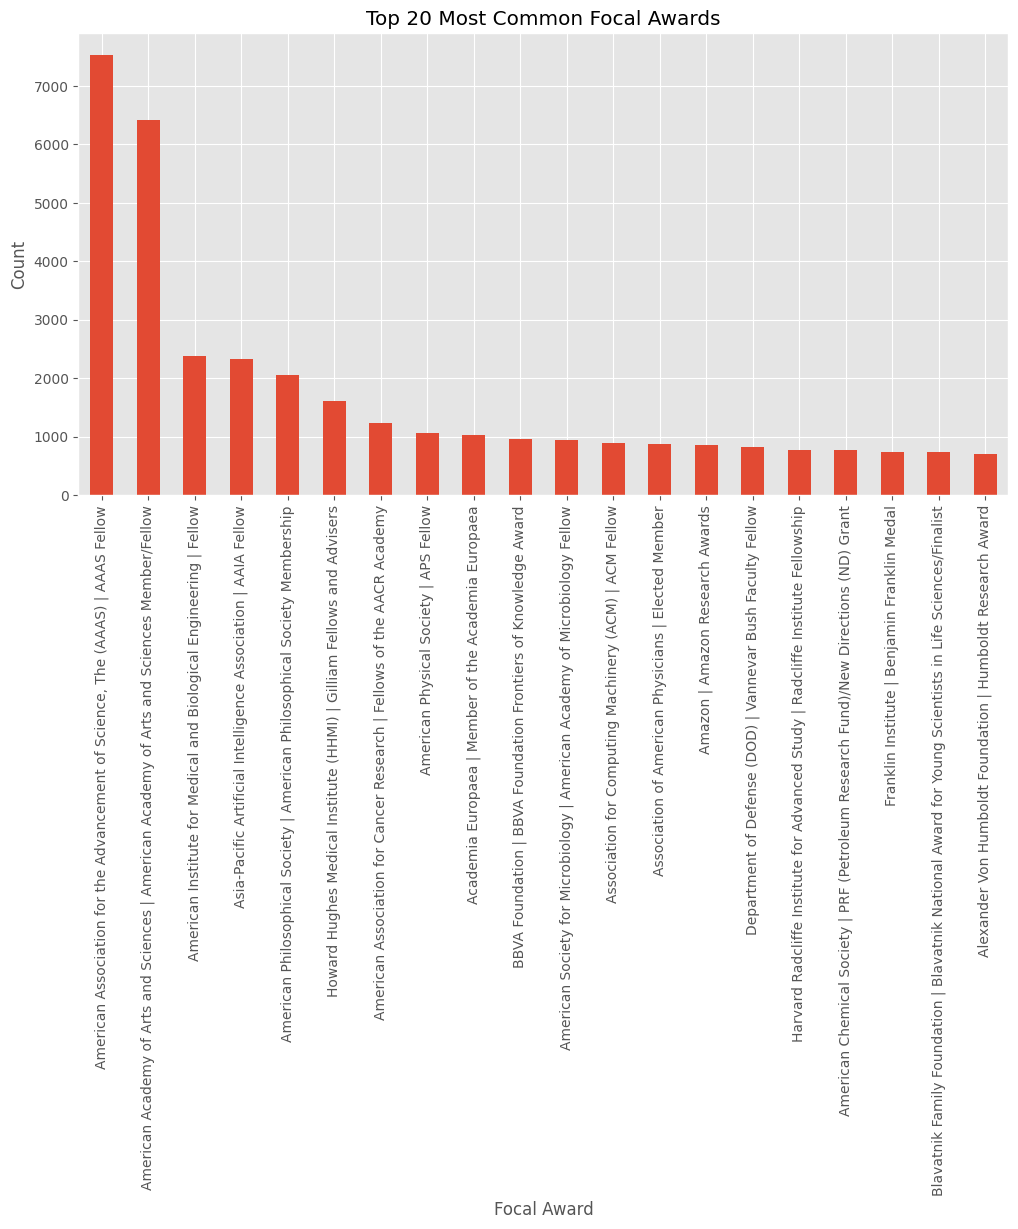

In [41]:
# most common focal awards, top 20

plt.figure(figsize=(12, 6))
df["Focal Award"].value_counts().nlargest(20).plot(kind="bar")
plt.xlabel("Focal Award")
plt.ylabel("Count")
plt.title("Top 20 Most Common Focal Awards")
plt.xticks(rotation=90)
plt.show()

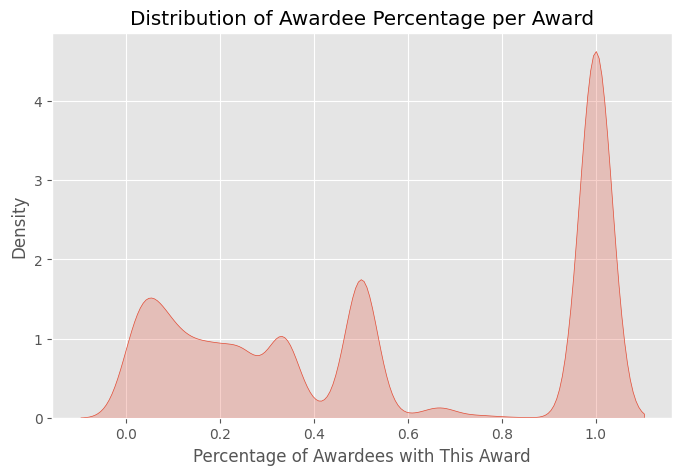

In [42]:
# distribution of percentage of awardees with this award

plt.figure(figsize=(8, 5))
sns.kdeplot(df["Percentage of Awardees with This Award"], fill=True)
plt.xlabel("Percentage of Awardees with This Award")
plt.ylabel("Density")
plt.title("Distribution of Awardee Percentage per Award")
plt.show()